# Trial-averaged PCA across cortical areas

Applying PCA per cortical area to trial-averaged responses, asking whether the three stimulus classes (Clip, Monet2, Trippy) occupy distinct regions of population state space and whether the strength of that separation differs across areas (V1, AL, LM, RL).


## How to use this notebook

The pipeline is **session-swappable**: every session-specific value is read from data, and outputs are partitioned by session subdirectory. To run on a different session, change `SESSION` in the configuration block below and restart the kernel.

## Part 0: Setup

In [1]:
import os
from pathlib import Path

# The notebooks import `scripts.*` and write `figures/…`, `results/…`
# relative to the repo root. If the kernel was started inside `notebooks/`
# (JupyterLab default), move up one level so both resolve.
if not Path("scripts").is_dir() and Path("../scripts").is_dir():
    os.chdir("..")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.io as pio

import scripts.microns_eda as microns_eda
import scripts.experiment1_utils as pca_utils

In [2]:
# Apply the presentation palette + white-background style globally.
from scripts.neuro_palette import apply_style
apply_style()

### Configuration

We run the label-permutation null with `N_SHUFFLES = 1000` for the primary (all-neurons) and log-sensitivity analyses, and `N_SHUFFLES_CONTROL = 100` inside the 60-subsample equal-population control (10× cheaper; that control is a ranking check). Each CSV reports the raw empirical p-value and a Holm-adjusted `p_holm` over the 4 areas of each metric. An empirical p cannot go below `1/(N_SHUFFLES+1)`; with 1000 shuffles the floor is 0.001, and Holm over 4 tests turns it into 0.004.

In [3]:
# === Configuration block: every tunable lives here. ===
SESSION = "7_5"

# Preprocessing
N_FRAMES_TRUNCATE = 75              # Clip trial length; truncates Monet2/Trippy from 113.
TREADMILL_OUTLIER_THRESHOLD = 1.0   # Same threshold as EDA's running-outlier filter.

# PCA / metrics
N_COMPONENTS = 10
N_BALANCE_REPLICATES = 20           # subsamples per balanced silhouette.
N_SHUFFLES = 1000                   # silhouette + classifier nulls (all-neurons, log). Floor p = 1/1001.
N_SHUFFLES_CONTROL = 100            # per subsample in the equal-population control (60 runs).
N_POPULATION_SUBSAMPLES = 20        # for the equal-population control.
N_FOLDS_CV = 5

# Reproducibility
RANDOM_SEED = 42

# Paths
# Data directory: <DATADIR>/functional/microns_functional.h5. Default is the
# git-ignored data/ folder inside the repo; override with MICRONS_DATADIR.
DATADIR = Path(os.environ.get("MICRONS_DATADIR", "data"))
FIGURES_DIR = Path(f"figures/exp1_trial_averaged_pca/{SESSION}")
RESULTS_DIR = Path(f"results/exp1_trial_averaged_pca/{SESSION}")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

np.random.seed(RANDOM_SEED)

print(f"SESSION       = {SESSION}")
print(f"DATADIR       = {DATADIR}")
print(f"FIGURES_DIR   = {FIGURES_DIR}")
print(f"RESULTS_DIR   = {RESULTS_DIR}")

SESSION       = 7_5
DATADIR       = ../neuroscience
FIGURES_DIR   = figures/exp1_trial_averaged_pca/7_5
RESULTS_DIR   = results/exp1_trial_averaged_pca/7_5


### Sanity check

We open the dataset, verify session `{SESSION}` is loadable, recompute `clean_trial_indices` from the EDA's running-outlier rule, and print the per-class composition.

In [4]:
# === Sanity check ===
reader = microns_eda.open_dataset(DATADIR)
sessions = microns_eda.list_sessions(DATADIR)
assert SESSION in sessions, f"session {SESSION!r} not in {sessions}"
print(f"Found {len(sessions)} sessions; using {SESSION!r}.")

meta = microns_eda.get_session_meta(DATADIR, SESSION)
print(f"  n_neurons (read from data) = {meta['n_neurons']}")

# Build per-trial treadmill means via the same path as EDA.
n_trials = meta["n_trials"]
per_trial_tread_means = np.empty(n_trials, dtype=np.float64)
for i in range(n_trials):
    trial = microns_eda.load_trial(reader, DATADIR, SESSION, i)
    per_trial_tread_means[i] = np.nanmean(trial["treadmill"])

clean_trial_indices, running_mask = microns_eda.compute_clean_trial_indices(
    per_trial_tread_means, threshold=TREADMILL_OUTLIER_THRESHOLD,
)

# Stim labels for the clean subset.
stim_map = microns_eda.build_stim_type_map(reader, SESSION)
stim_types_per_trial = np.array([
    stim_map[h.decode() if isinstance(h, bytes) else h]
    for h in meta["condition_hashes"]
])
labels = stim_types_per_trial[clean_trial_indices]

# Read class counts from data: never hard-code.
class_counts = pd.Series(labels).value_counts().to_dict()
print(f"  n_trials (total)            = {n_trials}")
print(f"  n_trials (after running QC) = {len(clean_trial_indices)}")
print(f"  per-class breakdown (clean):")
for k in sorted(class_counts):
    print(f"    {k:8s} {class_counts[k]}")

assert len(clean_trial_indices) > 0, "No clean trials remain, threshold too low?"
assert len(class_counts) >= 2, "Need at least 2 stim classes for separability."
print("Sanity check passed.")

Found 14 sessions; using '7_5'.
  n_neurons (read from data) = 8194
  n_trials (total)            = 464
  n_trials (after running QC) = 453
  per-class breakdown (clean):
    Clip     377
    Monet2   38
    Trippy   38
Sanity check passed.


## Part 1: Preprocess and build per-area matrices

We load the full-session response matrix, apply the locked-in preprocessing recipe, then collapse each clean trial to one vector per cortical area.

**What's locked in (see spec):**

- **Detrend.** Photobleaching makes the calcium indicator dimmer over the course of the recording (the EDA measured a ~45% decrease across `7_5`). Without correction, the slow fade dominates the first principal component and drowns out anything stimulus-related. We subtract a per-neuron linear fit to remove the fade while leaving moment-to-moment activity untouched.
- **Z-score per neuron.** Different neurons fluoresce at different baseline brightness. After z-scoring (subtract mean, divide by std), every neuron contributes on the same scale, so PCA isn't dominated by the brightest few neurons.
- **Truncate to 75 frames.** Clip trials are 75 frames; Monet2 and Trippy are 113. Truncating Monet2/Trippy makes the trial-averaged vectors directly comparable across stimulus classes.
- **Trial-average across time.** Each trial collapses to a single vector summarising its average activity per neuron.
- **One matrix per cortical area.** V1, AL, LM, RL are analysed independently, so each area's PCA is fit on its own column subset.

We expect: four matrices with `len(clean_trial_indices) = 453` rows for `7_5` and column counts matching the EDA cohort table (V1 ≈ 5,485, LM ≈ 1,262, RL ≈ 1,033, AL ≈ 414).

In [5]:
# Load the full neuron × time matrix and trial boundaries.
print("loading full session responses...")
responses, trial_boundaries, _ = microns_eda.load_session_responses(
    reader, DATADIR, SESSION
)
print(f"  responses shape       = {responses.shape}")
print(f"  trial_boundaries len  = {len(trial_boundaries)}")
print(f"  total timesteps       = {responses.shape[1]}")

loading full session responses...
  responses shape       = (8194, 37840)
  trial_boundaries len  = 465
  total timesteps       = 37840


In [6]:
# Stage A: full-timeseries preprocessing (log? -> detrend -> z-score).
responses_pp = pca_utils.preprocess_responses(responses, apply_log=False)
assert responses_pp.shape == responses.shape
print(f"preprocess_responses applied; shape unchanged at {responses_pp.shape}.")

# Stage B: trial-level: truncate, mask, per-area split + average.
per_area = pca_utils.build_per_area_matrices(
    responses_pp,
    trial_boundaries=trial_boundaries,
    clean_trial_indices=clean_trial_indices,
    brain_areas=meta["brain_areas"],
    n_frames=N_FRAMES_TRUNCATE,
)

print(f"\nper-area matrices ({len(clean_trial_indices)} clean trials):")
total_neurons = 0
for area in sorted(per_area.keys()):
    X = per_area[area]
    total_neurons += X.shape[1]
    print(f"  {area:5s}: shape {X.shape!s:18s} "
          f"(NaN: {np.isnan(X).sum()}; zero-variance cols: {(X.std(axis=0) == 0).sum()})")
print(f"  total neurons = {total_neurons} (matches meta: {total_neurons == meta['n_neurons']})")

# Sanity asserts.
for area, X in per_area.items():
    assert X.shape[0] == len(clean_trial_indices), f"{area} row count wrong"
    assert not np.isnan(X).any(), f"{area} has NaNs"
    # Constant columns would break PCA / silhouette; warn rather than assert.
    if (X.std(axis=0) == 0).any():
        print(f"  WARNING: {area} has constant column(s), PCA will treat as zero-variance.")

preprocess_responses applied; shape unchanged at (8194, 37840).

per-area matrices (453 clean trials):
  AL   : shape (453, 414)         (NaN: 0; zero-variance cols: 0)
  LM   : shape (453, 1262)        (NaN: 0; zero-variance cols: 0)
  RL   : shape (453, 1033)        (NaN: 0; zero-variance cols: 0)
  V1   : shape (453, 5485)        (NaN: 0; zero-variance cols: 0)
  total neurons = 8194 (matches meta: True)


## Part 2: PCA on V1

V1 is our reference area: it dominates the population (5,485 / 8,194 neurons) and its low-level feature tuning means we expect strong stimulus-class separation. We fit PCA on the trial-averaged matrix `X_V1`, visualise the top-3 PCs as a 2-D scatter and a 3-D Plotly scatter, and inspect the explained variance plot (scree plot).

**What we're looking for:**

- 2-D scatter: three colour clouds with different centroids; some overlap is expected.
- 3-D scatter: separation that wasn't visible in 2-D may resolve along PC3.
- Scree plot: how much of the total variance lives in the top 3 PCs we're visualising. A high cumulative percentage means we're looking at the dominant signal; a low percentage means we're looking at a peripheral one.

In [7]:
pca_V1, X_V1_pcs = pca_utils.fit_pca(
    per_area["V1"], n_components=N_COMPONENTS, random_state=RANDOM_SEED,
)
print(f"V1 PCA fitted; X_pcs shape = {X_V1_pcs.shape}")
print(f"  top-3 cumulative variance = {100 * pca_V1.explained_variance_ratio_[:3].sum():.1f}%")
print(f"  top-10 cumulative         = {100 * pca_V1.explained_variance_ratio_[:10].sum():.1f}%")

V1 PCA fitted; X_pcs shape = (453, 10)
  top-3 cumulative variance = 16.4%
  top-10 cumulative         = 30.7%


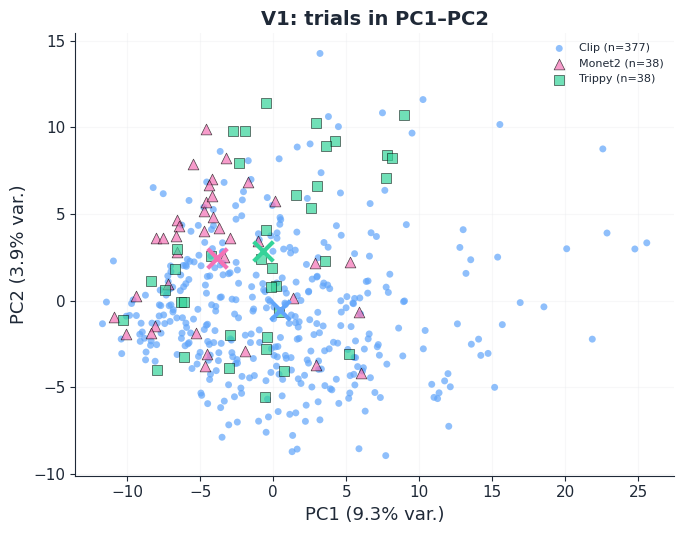

In [8]:
# 2-D scatter (matplotlib, for the report).
fig, ax = plt.subplots(figsize=(7, 5.5))
pca_utils.plot_pca_2d(X_V1_pcs, labels, area_name="V1", pca=pca_V1, ax=ax)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "2_pca_v1_2d.png", dpi=150)
plt.show()

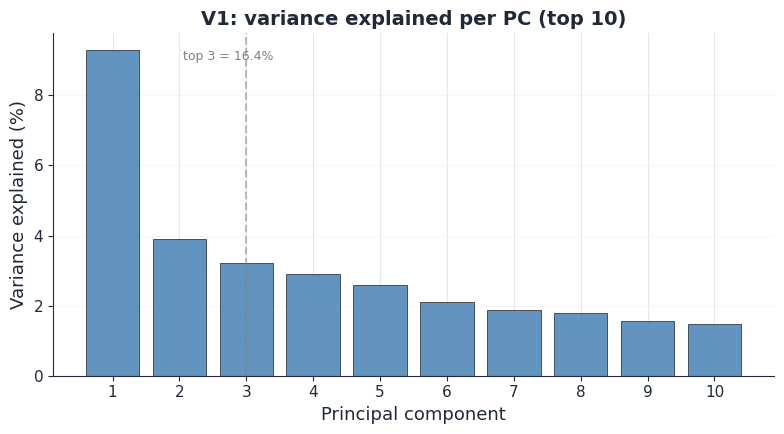

V1 full PCA: 453 components fit


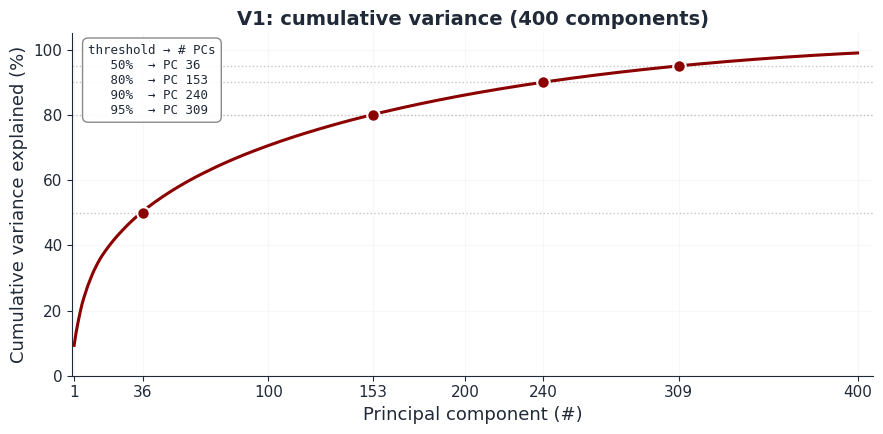

In [9]:
# Variance explained per PC: the elbow plot.
fig, ax = plt.subplots(figsize=(8, 4.5))
pca_utils.plot_scree(pca_V1, area_name="V1", n_show=400, ax=ax)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "2_pca_v1_scree.png", dpi=150)
plt.show()

# Cumulative variance: fit a separate PCA with ALL components so we can see
# the curve climb to 100% and read off the PC at which each variance threshold
# is reached. (The primary `pca_V1` only retains the top-10 PCs needed for the
# downstream scatters and silhouette; here we want the full picture.)
from sklearn.decomposition import PCA as _PCA
pca_V1_full = _PCA(whiten=False, random_state=RANDOM_SEED).fit(per_area["V1"])
print(f"V1 full PCA: {len(pca_V1_full.explained_variance_ratio_)} components fit")

fig, ax = plt.subplots(figsize=(9, 4.5))
pca_utils.plot_cumulative_variance(pca_V1_full, area_name="V1", ax=ax, n_show=400)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "2_pca_v1_cumulative.png", dpi=150)
plt.show()

In [10]:
# 3-D Plotly scatter (interactive; saved to HTML for the oral presentation).
fig3d_v1 = pca_utils.plot_pca_3d_plotly(
    X_V1_pcs, labels, area_name="V1", pca=pca_V1
)
out_html = FIGURES_DIR / "2_pca_v1_3d.html"
fig3d_v1.write_html(str(out_html))
print(f"saved {out_html}")
fig3d_v1.show()

saved figures/exp1_trial_averaged_pca/7_5/2_pca_v1_3d.html


### Interpretation: V1 (PC1–3)

The three stimulus classes do form visibly different clusters, but the picture is more **"Clip vs. the two synthetics"** than three cleanly separated groups. In the PC1–PC2 panel, the Monet2 and Trippy centroids sit close together in the upper-left region, both shifted toward negative PC1 and positive PC2, while the Clip centroid sits near the origin and its trials spread far to the right along PC1, into territory the synthetic classes never reach. Some of that rightward spread is just because Clip has ~10× more trials and therefore samples more of the tail, but the centroid offset itself is real.

Rotating the 3D plot doesn't change the story: PC3 adds another 3.2% of variance but doesn't pull Monet2 and Trippy apart, they keep overlapping from every angle. So in PC1–2 the Clip class mean is further from both parametric-stimulus class means than those two are from each other. Monet2 and Trippy are both computer-generated noise stimuli and Clip is video, but "naturalness" is not a stimulus feature the analysis can isolate: the classes also differ in low-level image statistics (luminance, contrast, motion energy) that were not controlled.

The top three PCs together only capture **16.4%** of V1's total variance: there is no small handful of axes that dominate. The cumulative-variance curve makes this concrete: reaching 50% of the variance already takes 36 PCs, 80% takes 153, and **95% requires 309 of the 453 available components**. That is a strong "no" to the question of whether V1's trial-averaged activity lives on a much lower-dimensional linear subspace: at least not under linear PCA, the geometry is genuinely high-dimensional. So when we say class structure is visible in PC1–3, we mean it lives in a small slice of relatively flat variance landscape. The classifier in Part 3 (which uses all 5,485 neurons, not just three PCs) will tell us whether stronger separation lives outside this slice.

## Part 3: Diagnostics on V1

### What is a silhouette score, and why do we balance it?

The **silhouette score** measures, for each trial, how tightly each point sits with neighbours of the same stimulus class versus how far it sits from neighbours of other classes. The per-trial score ranges from −1 (worse than random; the trial sits closer to other classes) to +1 (perfectly clustered with same-class neighbours). 0 means they're on the boundary. The dataset-level silhouette is the average over trials. Higher means cleaner separation.

**Why balance:** In `7_5` Clip has 377 trials but Monet2 and Trippy have only 38 each. Raw silhouette gives Clip's compactness ten times more weight than the minority classes', which biases the score and makes it hard to interpret across areas. We instead compute the silhouette on a **balanced 38 / 38 / 38 subsample**, average over 20 such subsamples, and use that average as the observed value. The minority count is read from the data, so this works automatically on other sessions.

We compare the observed silhouette to a **null distribution** built by shuffling stimulus labels 100 times. If the observed silhouette exceeds the 95th percentile of the null (empirical p < 0.05), the cluster structure we see is unlikely to be a coincidence.

In [11]:
print("computing balanced silhouette + null on V1 (this takes ~30-60 s)...")
sil_V1 = pca_utils.silhouette_balanced(
    X_V1_pcs[:, :3], labels,
    n_replicates=N_BALANCE_REPLICATES, seed=RANDOM_SEED,
)
sil_null_V1 = pca_utils.silhouette_balanced_null(
    X_V1_pcs[:, :3], labels,
    n_replicates=N_BALANCE_REPLICATES,
    n_shuffles=N_SHUFFLES, seed=RANDOM_SEED + 1,
)
sil_V1_p = float((1 + (sil_null_V1 >= sil_V1["observed"]).sum()) / (1 + N_SHUFFLES))
print(f"  observed silhouette  = {sil_V1['observed']:+.3f}  (n_per_class={sil_V1['n_per_class']})")
print(f"  null median (shuffle)= {np.median(sil_null_V1):+.3f}")
print(f"  empirical p          = {sil_V1_p:.3f}")

computing balanced silhouette + null on V1 (this takes ~30-60 s)...
  observed silhouette  = +0.021  (n_per_class=38)
  null median (shuffle)= -0.037
  empirical p          = 0.001


### Reading the V1 silhouette result

**Observed silhouette = +0.021.** The score is barely above zero: in PC1–3 space, a typical V1 trial is only marginally closer to its own stimulus class than to the nearest other class. The clusters exist, but they overlap heavily.

**Null median = −0.036.** This is what we'd expect by chance. We shuffled the stimulus labels 100 times and recomputed the balanced silhouette each time; half the shuffles came in at or below −0.036. Two things to notice:

1. The null is *negative*, not zero. That's because of how the balanced average works on this geometry, since random labels don't produce zero-mean silhouettes. This is exactly why we built an empirical null instead of just comparing to 0: it tells us what "no class structure" actually looks like *for this dataset*, rather than assuming.
2. Our observed +0.021 sits about 0.057 units above the null median. Small in absolute terms, but consistently above the noise floor.

**Empirical p = 0.001.** Out of the 1000 shuffles, none beat our observed silhouette (0.001 is the smallest p-value the procedure can produce: `(1 + #shuffles ≥ observed) / (1 + n_shuffles) = 1/1001`; Holm-adjusted over the four areas, 0.004). So the class means are separated along PC1–3 more than random label assignments would produce, even though the separation is small.

**The takeaway.** V1's trial-averaged responses *do* carry stimulus-class information in the top-3 PCs, but the geometric separation in that subspace is weak. This matches what we saw in the scatter plots: the centroids are offset, but there's a lot of overlap. The next diagnostic (the classifier on the full neuron matrix) will tell us whether stronger separation exists outside PC1–3, where the silhouette can't see it.

### Variance ≠ separability: why we add a classifier metric

PCA finds the directions of **highest variance** in the data. That isn't the same as the directions that **separate stimulus classes**. If the class signal lives in PC4 or PC5 instead of PC1–3, a silhouette in top-3 PC space will miss it.

We therefore add a complementary metric: **5-fold cross-validated multinomial logistic regression accuracy on the full trial-averaged matrix** (no PCA reduction). The classifier sees every neuron and finds the best linear combinations for separating Clip / Monet2 / Trippy, regardless of which PCs they happen to align with. The reference is the **majority-class baseline**: a classifier that always predicts Clip would get 377/453 ≈ 83.2% on `7_5`. Anything meaningfully above this is real signal.

The two numbers answer different questions and cannot "agree" or "disagree". PCA is an unsupervised variance decomposition, not a classifier: the silhouette in PC1–3 measures how well the class labels line up with the three highest-variance directions of the trial-averaged activity. The decoder measures whether the labels are linearly recoverable from the full population. A decoder well above chance together with a silhouette near zero simply means the class information is present but is not concentrated in the first three principal components, which, with the top-3 PCs explaining only ~16% of the variance, is what one would expect.

In [12]:
print("computing classifier + null on V1 (this takes ~60-120 s)...")
clf_V1 = pca_utils.classify_cv(
    per_area["V1"], labels, n_folds=N_FOLDS_CV, seed=RANDOM_SEED,
)
clf_null_V1 = pca_utils.classify_cv_null(
    per_area["V1"], labels,
    n_folds=N_FOLDS_CV, n_shuffles=N_SHUFFLES, seed=RANDOM_SEED + 2,
)
clf_V1_p = float((1 + (clf_null_V1 >= clf_V1["observed"]).sum()) / (1 + N_SHUFFLES))
print(f"  observed accuracy   = {clf_V1['observed']:.3f}")
print(f"  chance (majority)   = {clf_V1['chance']:.3f}")
print(f"  null median         = {np.median(clf_null_V1):.3f}")
print(f"  empirical p         = {clf_V1_p:.3f}")

computing classifier + null on V1 (this takes ~60-120 s)...
  observed accuracy   = 0.989
  chance (majority)   = 0.832
  null median         = 0.815
  empirical p         = 0.001


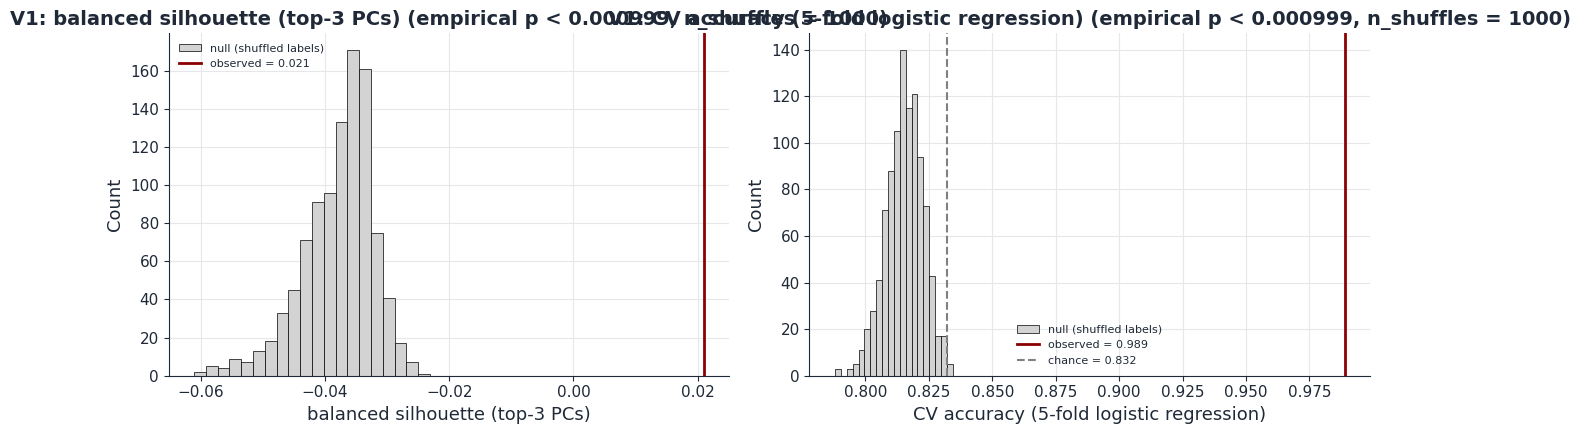

In [13]:
# Two histograms side-by-side.
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
pca_utils.plot_silhouette_with_null(
    sil_V1["observed"], sil_null_V1, area_name="V1", ax=axes[0],
)
pca_utils.plot_classifier_with_null(
    clf_V1["observed"], clf_null_V1, area_name="V1",
    chance=clf_V1["chance"], ax=axes[1],
)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "3_v1_diagnostics.png", dpi=150)
plt.show()

### Interpretation: V1 diagnostics

The two metrics both reach significance, but they measure different things and their magnitudes are not comparable.

- **Silhouette in PC1–3 = +0.021** (null median −0.037, p = 0.001, p_holm = 0.004). Above the null, but barely; the clusters in the visualized subspace overlap heavily.
- **Classifier accuracy on the full matrix = 0.989** (majority baseline 0.832, null median 0.815, p = 0.001, p_holm = 0.004). Near-ceiling.

Both p-values sit at the empirical floor of the test (1/1001 = 0.001, where the +1 correction prevents a degenerate p = 0 result), so the three stimulus classes are linearly recoverable from V1's trial-averaged activity. But the *strength gap* between the two metrics tells us something deeper about **where** that encoding lives.

**Reading the two numbers together.**

A linear classifier separating 3 classes only needs **at most 2 hyperplanes** to do the job. So in principle, the entire stimulus-class signal could live in a 2-to-10-dimensional subspace. The fact that the classifier hits 98.9% accuracy is direct evidence that such a low-dimensional separating subspace **exists** somewhere inside V1's 5,485-neuron activity.

But PC1–3, the directions PCA hands us, only contain 16.4% of the total variance, and the silhouette tells us the class signal is not concentrated there. So we have a paradox that resolves cleanly once realized that  PCA and class-separation are answering different questions:

- **PCA asks:** "Along which directions does V1 activity vary the most?" Answer: directions that mix together arousal, slow drift, eye movements, and many other sources of variability, most of which are *not* stimulus-class.
- **The classifier asks:** "Along which directions do the three stimulus classes differ the most?" Answer: a small subspace that PCA happens to consider not very explanatory, because it has low total variance.

These two subspaces need not coincide. A 3-class linear decoder uses a decision subspace of at most 2 dimensions, so the class means are linearly separable in a low-dimensional subspace of the 5,485-neuron space; that subspace is simply not spanned by the first three principal components. This is not a failure of PCA, which was never asked to separate classes: it is the statement that class identity accounts for a small share of the trial-to-trial variance. A supervised projection (e.g. LDA) would show the separating directions directly; none is run in this repository.

This is consistent with the scree-plot finding earlier: V1's *overall* activity geometry really is high-dimensional (309 PCs for 95% of variance), but within that high-dimensional cloud, the stimulus-class signal occupies a much smaller subspace that PCA can't isolate because it's not where the bulk of the variance lives.

**Practical consequences for the rest of the project.**

First, when comparing across cortical areas in Part 5, the two metrics should be read separately: a weak silhouette in an area means the class means are not separated along that area's top-3 variance directions; the decoder accuracy says whether the classes are linearly recoverable at all. Always cross-check with the classifier before drawing conclusions. Second, trial-averaging discards within-trial dynamics; experiment 2 keeps the time axis. No supervised or nonlinear embedding is run in this repository.

## Part 4: Repeat on AL, LM, RL

We apply the V1 pipeline to each of the higher visual areas in turn. Each area's PCA is fit independently: its PC axes are different from V1's, so the *coordinates* are not comparable. What we'll compare across areas (in Part 5) is the *strength of cluster separation* as captured by the silhouette and classifier metrics.

**What we're looking for:**

- Does V1's clear separation pattern hold up in the higher areas, or does the geometry reorganise?
- One reasonable prior: V1 strongest (low-level features differ heavily across stimuli), higher areas weaker or with Monet2 and Trippy collapsing toward each other (both synthetic, lacking semantic content) while Clip stands apart.

In [14]:
all_area_results = {"V1": {
    "area_name": "V1",
    "n_neurons": int(per_area["V1"].shape[1]),
    "pca": pca_V1,
    "X_pcs": X_V1_pcs,
    "silhouette": {**sil_V1, "null": sil_null_V1, "empirical_p": sil_V1_p},
    "classifier": {**clf_V1, "null": clf_null_V1, "empirical_p": clf_V1_p},
}}

# AL, LM, RL via run_area_pipeline (one call each).
for area in ["AL", "LM", "RL"]:
    print(f"\n=== {area} ===")
    print("  running PCA + silhouette (+ null) + classifier (+ null)...")
    res = pca_utils.run_area_pipeline(
        per_area[area], labels, area_name=area,
        n_components=N_COMPONENTS,
        n_balance_replicates=N_BALANCE_REPLICATES,
        n_shuffles=N_SHUFFLES,
        n_folds_cv=N_FOLDS_CV,
        seed=RANDOM_SEED + ord(area[0]),  # area-distinct seed
    )
    all_area_results[area] = res
    print(f"  n_neurons       = {res['n_neurons']}")
    print(f"  silhouette obs  = {res['silhouette']['observed']:+.3f}  "
          f"(p={res['silhouette']['empirical_p']:.3f})")
    print(f"  classifier obs  = {res['classifier']['observed']:.3f}  "
          f"(chance={res['classifier']['chance']:.3f}, p={res['classifier']['empirical_p']:.3f})")


=== AL ===
  running PCA + silhouette (+ null) + classifier (+ null)...
  n_neurons       = 414
  silhouette obs  = -0.018  (p=0.001)
  classifier obs  = 0.947  (chance=0.832, p=0.001)

=== LM ===
  running PCA + silhouette (+ null) + classifier (+ null)...
  n_neurons       = 1262
  silhouette obs  = +0.031  (p=0.001)
  classifier obs  = 0.980  (chance=0.832, p=0.001)

=== RL ===
  running PCA + silhouette (+ null) + classifier (+ null)...
  n_neurons       = 1033
  silhouette obs  = +0.011  (p=0.001)
  classifier obs  = 0.978  (chance=0.832, p=0.001)


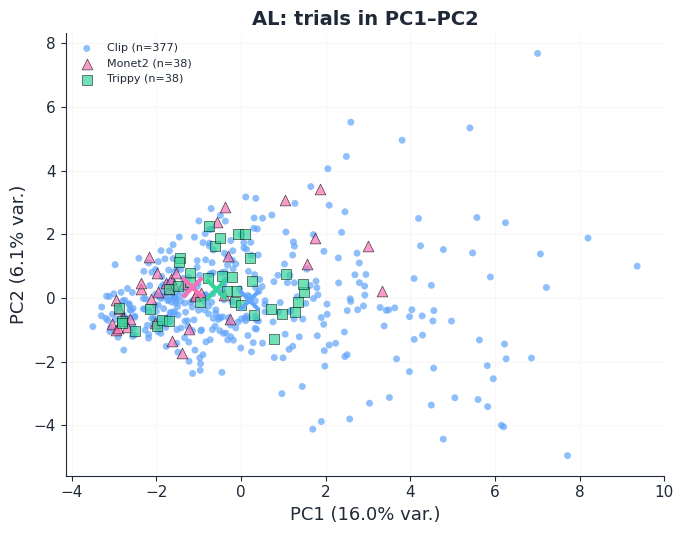

saved figures/exp1_trial_averaged_pca/7_5/4_pca_al_3d.html


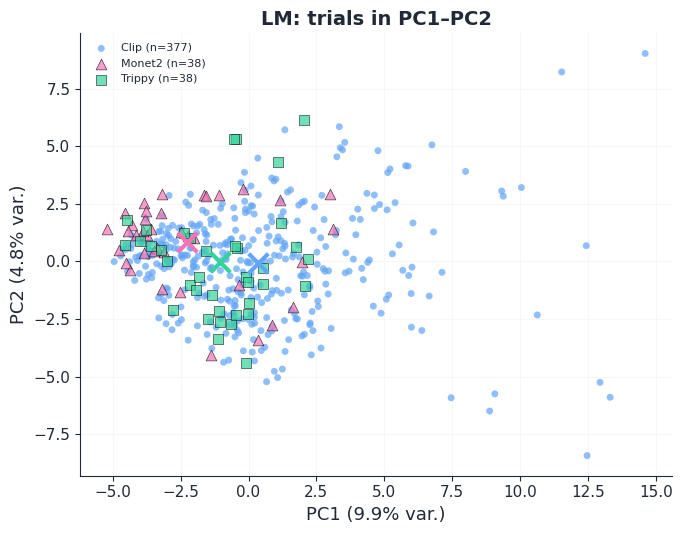

saved figures/exp1_trial_averaged_pca/7_5/4_pca_lm_3d.html


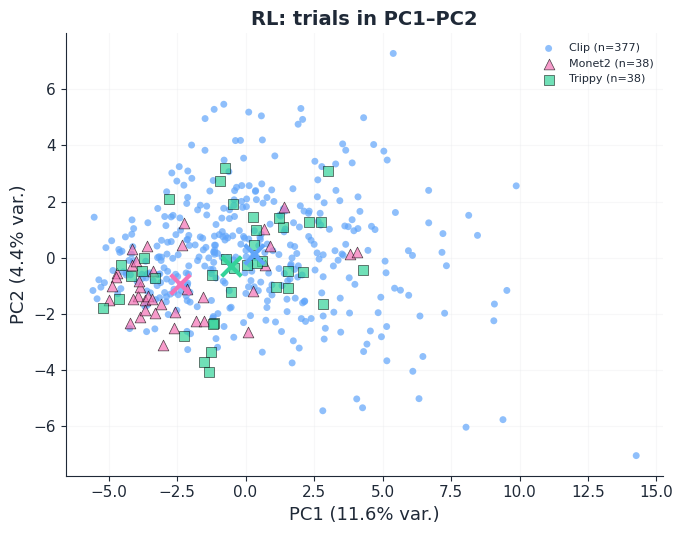

saved figures/exp1_trial_averaged_pca/7_5/4_pca_rl_3d.html


In [15]:
# Per-area 2-D and 3-D scatters; saved per area.
for area in ["AL", "LM", "RL"]:
    res = all_area_results[area]
    fig, ax = plt.subplots(figsize=(7, 5.5))
    pca_utils.plot_pca_2d(
        res["X_pcs"], labels, area_name=area, pca=res["pca"], ax=ax,
    )
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / f"4_pca_{area.lower()}_2d.png", dpi=150)
    plt.show()

    fig3d = pca_utils.plot_pca_3d_plotly(
        res["X_pcs"], labels, area_name=area, pca=res["pca"],
    )
    out_html = FIGURES_DIR / f"4_pca_{area.lower()}_3d.html"
    fig3d.write_html(str(out_html))
    print(f"saved {out_html}")

### Interpretation: AL, LM, RL

**Visually, the same "Clip vs. synthetics" pattern repeats in all three higher areas, but progressively weaker than in V1.** In every panel, the Monet2 (orange) and Trippy (green) centroids sit close together on the negative-PC1 side, while the Clip (blue) centroid sits near the origin and Clip trials spread far to the positive side. So the geometry is reorganized but shows the same coarse pattern: the Clip class mean is offset from the two parametric-stimulus class means, which sit close to each other (with the same caveat as for V1: this is a stimulus-set difference, not a "naturalness" feature).

**Numerically, the picture splits depending on which metric you trust.**

| Area | n  | silhouette | classifier |
|------|------|------------|------------|
| V1   | 5485 | +0.021 ✓   | 0.989 ✓    |
| AL   | 414  | −0.018 ✓   | 0.947 ✓    |
| LM   | 1262 | +0.031 ✓   | 0.980 ✓    |
| RL   | 1033 | +0.011 ✓   | 0.978 ✓    |

Two things stand out. First, **AL has a *negative* silhouette** (−0.018): its trials sit slightly closer to other classes than to their own in PC1–3 space, even though the classifier still hits 94.7%. This is the "classifier high, silhouette low" case from Part 3 in extreme form: in AL, the stimulus signal is very real but lives even further from the high-variance directions than in V1. PCA's view of AL is genuinely misleading.

Second, **LM has the *highest* silhouette** of all four areas (+0.031), edging out V1. This is unexpected if you assumed V1 would dominate, it's a hint that the trial-averaged class structure aligns slightly better with high-variance directions in LM than in V1. We shouldn't overread it yet, though, because LM has roughly 4× fewer neurons than V1, and population size affects both metrics. The equal-population control in Part 6 is what will tell us whether this LM advantage is real or a sampling artifact.

**One caveat about the silhouette p-values being significant.** Even AL's *negative* silhouette has p = 0.001, which seems paradoxical, how is "trials sit closer to other classes" a statistically significant result? It's because the null distribution is also negative (around −0.04 from Part 3), so −0.018 still beats the shuffles. The p-value tells us the geometry is non-random; it doesn't tell us the geometry is favorable. This is exactly why we need the classifier as a second metric.

**Bottom line.** All four areas reliably encode the three stimulus classes (every classifier > 94%), and all four show the same Clip-vs-synthetics asymmetry rather than three-way separation. V1 has the highest classifier accuracy; LM has the highest silhouette; AL is the area where PCA is most misleading. The cross-area bar charts in Part 5 will make these comparisons visual, and Part 6 will tell us how much of the ranking is driven by neuron count vs. real coding differences.

## Part 5: Cross-area comparison

We bring the four areas together: a 2 × 2 grid of scatter plots and two metric bar charts (silhouette and classifier accuracy), each annotated with the empirical p-value against the shuffled-label null.

**Important caveat for the scatter grid.** PC1 in V1 is not the same direction as PC1 in any other area, each PCA was fit independently on a different column subset. Compare the *pattern* of cluster separation across panels, not the coordinates.

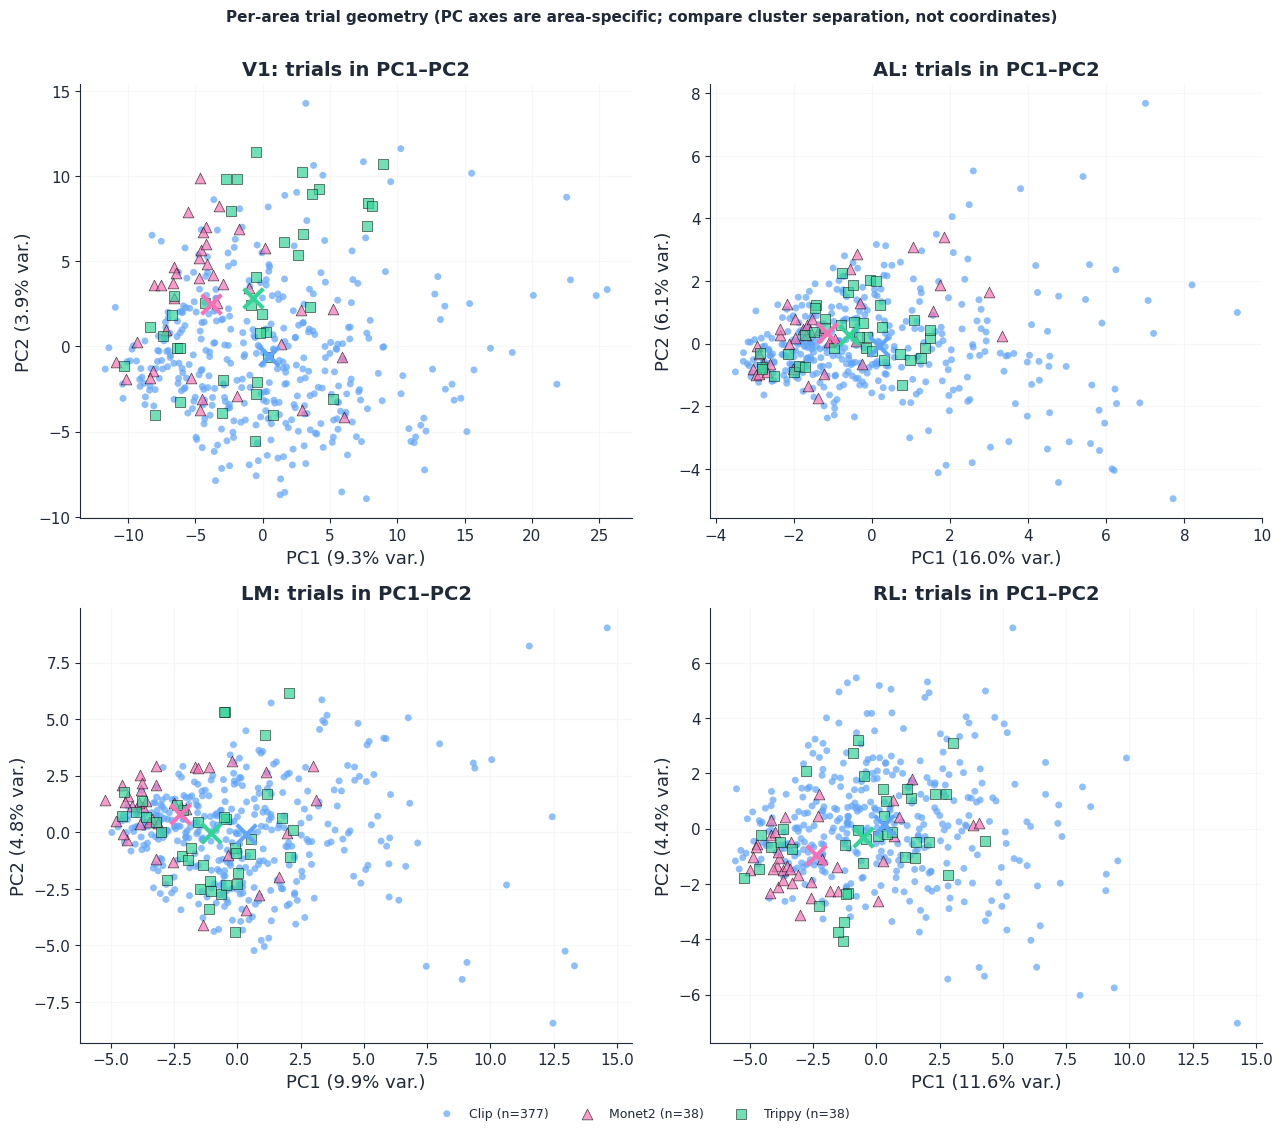

In [16]:
# 2 x 2 scatter grid.
fig = pca_utils.plot_cross_area_grid(all_area_results, labels, figsize=(13, 11))
fig.savefig(FIGURES_DIR / "5_cross_area_grid.png", dpi=150, bbox_inches="tight")
plt.show()

scripts/experiment1_utils.py:1145: UserWarning: You passed a edgecolor/edgecolors ('darkgrey') for an unfilled marker ('_').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(x[i], q50, color="white", edgecolor="darkgrey",
scripts/experiment1_utils.py:1145: UserWarning: You passed a edgecolor/edgecolors ('darkgrey') for an unfilled marker ('_').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(x[i], q50, color="white", edgecolor="darkgrey",


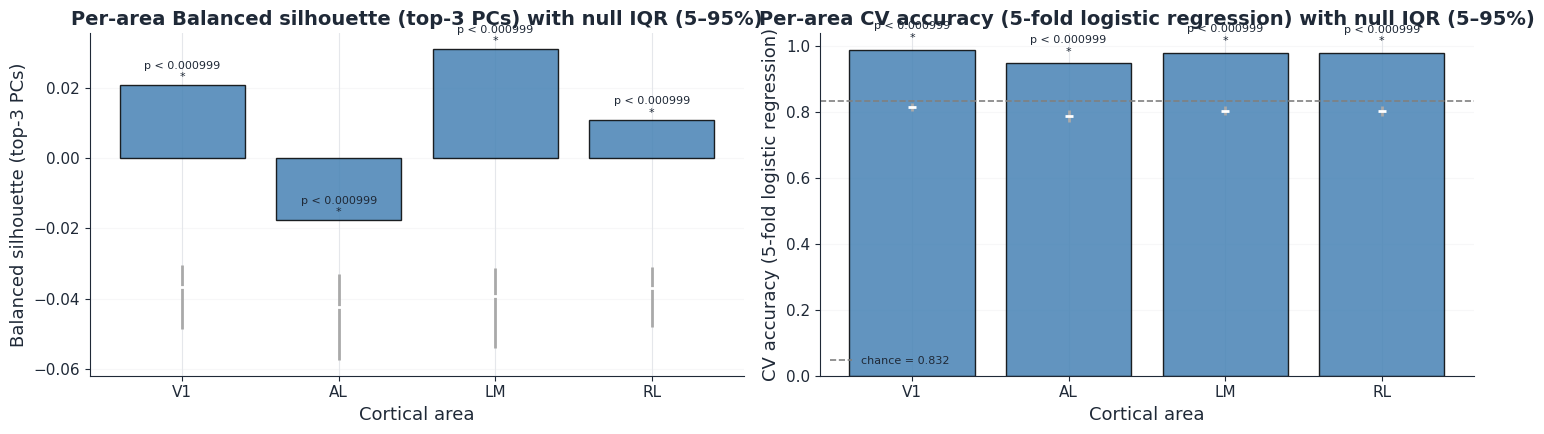

In [17]:
# Metric bar charts.
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
pca_utils.plot_cross_area_metric_bars(
    all_area_results, "silhouette", ax=axes[0],
)
pca_utils.plot_cross_area_metric_bars(
    all_area_results, "classifier",
    chance=all_area_results["V1"]["classifier"]["chance"],
    ax=axes[1],
)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "5_cross_area_metric_bars.png", dpi=150)
plt.show()

In [18]:
# Save the per-area numbers to the per-session results CSV (analysis="all_neurons").
rows = []
for area, res in all_area_results.items():
    for metric_name in ("silhouette", "classifier"):
        m = res[metric_name]
        rows.append({
            "area": area,
            "n_neurons": res["n_neurons"],
            "metric": metric_name,
            "observed": m["observed"],
            "null_p05": float(np.quantile(m["null"], 0.05)),
            "null_median": float(np.median(m["null"])),
            "null_p95": float(np.quantile(m["null"], 0.95)),
            "empirical_p_value": m["empirical_p"],
            "analysis": "all_neurons",
        })
rows_df = pd.DataFrame(rows)

# Holm-adjusted p-values, one family per metric within this analysis
# (4 areas each). Raw empirical p-values have a floor of 1/(N_SHUFFLES+1),
# so N_SHUFFLES must be large enough for alpha/m to be reachable.
df_ = rows_df
for metric_name in ("silhouette", "classifier"):
    fam = df_["metric"] == metric_name
    df_.loc[fam, "p_holm"] = pca_utils.holm_adjust(df_.loc[fam, "empirical_p_value"])
    df_.loc[fam, "n_tests"] = int(fam.sum())
rows_df = df_
results_df = rows_df
csv_path = RESULTS_DIR / "silhouette_scores.csv"
# If this run is re-running Phase 5 only, preserve other analyses' rows.
if csv_path.exists():
    existing = pd.read_csv(csv_path)
    existing = existing[existing["analysis"] != "all_neurons"]
    results_df = pd.concat([existing, results_df], ignore_index=True)
results_df.to_csv(csv_path, index=False)
print(f"wrote {csv_path}  ({len(results_df)} rows)")
results_df

wrote results/exp1_trial_averaged_pca/7_5/silhouette_scores.csv  (24 rows)


,area,n_neurons,metric,observed,null_p05,null_median,null_p95,empirical_p_value,analysis,p_holm,n_tests
0,AL,414,silhouette,-0.017560,-0.056311,-0.043830,-0.034506,0.009901,equal_population,NaN,NaN
1,AL,414,classifier,0.947033,0.770249,0.788156,0.803653,0.009901,equal_population,NaN,NaN
2,V1,414,silhouette,0.004056,-0.050235,-0.037430,-0.030543,0.000500,equal_population,NaN,NaN
3,V1,414,classifier,0.973468,0.765934,0.785861,0.803639,0.000500,equal_population,NaN,NaN
4,LM,414,silhouette,0.023403,-0.055636,-0.039831,-0.031396,0.000500,equal_population,NaN,NaN
5,LM,414,classifier,0.969096,0.768132,0.787973,0.805739,0.000500,equal_population,NaN,NaN
6,RL,414,silhouette,0.012521,-0.049524,-0.037438,-0.030920,0.000500,equal_population,NaN,NaN
7,RL,414,classifier,0.965824,0.766153,0.786007,0.805763,0.000500,equal_population,NaN,NaN
8,V1,5485,silhouette,0.021542,-0.038691,-0.033251,-0.030003,0.009901,log_sensitivity,NaN,NaN
9,V1,5485,classifier,0.988987,0.803541,0.816752,0.827817,0.009901,log_sensitivity,NaN,NaN


### Interpretation: cross-area comparison

**All four areas reliably encode the three stimulus classes.** Every silhouette and every classifier accuracy sits at the floor of the 1000-shuffle null (p = 0.001; Holm-adjusted over the four areas, p_holm = 0.004). Under the classifier, the area ranking is V1 (0.989) > LM (0.980) ≈ RL (0.978) > AL (0.947), V1 is on top as expected, but the gaps between areas are small (V1 beats AL by only ~4 percentage points). Under silhouette in PC1–3, the ranking *changes*: LM (+0.031) > V1 (+0.021) > RL (+0.011) > AL (−0.018). LM edges out V1, and AL goes negative.

**The two rankings differ because the two metrics measure different things.** Classifier accuracy reflects whether the classes are linearly recoverable from the full population; silhouette in PC1–3 reflects how far apart the class means are along each area's three highest-variance directions. AL illustrates this: 94.7% accuracy says the classes are linearly recoverable, while its negative silhouette says the class means are not separated along AL's top-3 PCs. Neither number is "wrong"; PCA is not a classifier. The rough story matches the prior, V1 strongest, higher areas reorganise, with one surprise (LM's silhouette beats V1's). Whether LM's edge is a real coding difference or a population-size effect is exactly what Part 6 is designed to test, since LM has ~4× fewer neurons than V1 and population size affects both metrics.

## Part 6: Equal-population sanity check

Population size differs sharply across areas: V1 has ~13× more neurons than AL. PCA on a larger population has more variance to distribute across components, and downstream metrics (silhouette, classifier accuracy) can be inflated for that reason alone, independently of how informative each individual neuron is. This phase confirms whether the cross-area differences we found in Part 5 reflect *information content* or *population size*.

**Procedure.**

1. Set `n_match = n_neurons(AL)` (read from data).
2. For V1, LM, RL: 20 random column subsamples to `n_match` columns each. For each subsample, refit PCA, recompute observed silhouette + classifier and their null distributions.
3. Compare median ± IQR of the matched runs against the all-neurons observed values.

**Decision.** If the cross-area ranking by metric persists under matched populations, the original difference reflects neural information content. If V1's lead disappears, it was a population-size artefact.

In [19]:
n_match = all_area_results["AL"]["n_neurons"]
print(f"n_match (AL neuron count, read from data) = {n_match}")
print(f"n_subsamples per area                     = {N_POPULATION_SUBSAMPLES}")
print(f"n_shuffles per subsample                  = {N_SHUFFLES_CONTROL}")
print(f"\nThis cell is the most expensive in the notebook "
      f"(~10–20 minutes for V1, less for LM/RL).")

n_match (AL neuron count, read from data) = 414
n_subsamples per area                     = 20
n_shuffles per subsample                  = 100

This cell is the most expensive in the notebook (~10–20 minutes for V1, less for LM/RL).


In [20]:
# AL contributes a single 1-element list (no subsampling).
matched_results: dict[str, list[dict]] = {
    "AL": [all_area_results["AL"]],
}

for area in ["V1", "LM", "RL"]:
    print(f"\n=== {area} ({per_area[area].shape[1]} -> {n_match} neurons) ===")
    matched_results[area] = []
    for s in range(N_POPULATION_SUBSAMPLES):
        X_sub, _ = pca_utils.match_population_size(
            per_area[area], n_match=n_match, seed=RANDOM_SEED + s,
        )
        res = pca_utils.run_area_pipeline(
            X_sub, labels, area_name=area,
            n_components=N_COMPONENTS,
            n_balance_replicates=N_BALANCE_REPLICATES,
            n_shuffles=N_SHUFFLES_CONTROL,
            n_folds_cv=N_FOLDS_CV,
            seed=RANDOM_SEED + s + ord(area[0]),
        )
        matched_results[area].append(res)
        print(f"  sub {s+1:2d}: sil={res['silhouette']['observed']:+.3f}  "
              f"clf={res['classifier']['observed']:.3f}")


=== V1 (5485 -> 414 neurons) ===
  sub  1: sil=+0.016  clf=0.974
  sub  2: sil=+0.029  clf=0.962
  sub  3: sil=+0.030  clf=0.974
  sub  4: sil=+0.001  clf=0.969
  sub  5: sil=+0.002  clf=0.969
  sub  6: sil=-0.002  clf=0.978
  sub  7: sil=+0.001  clf=0.974
  sub  8: sil=+0.005  clf=0.967
  sub  9: sil=+0.022  clf=0.965
  sub 10: sil=+0.045  clf=0.978
  sub 11: sil=+0.008  clf=0.962
  sub 12: sil=+0.018  clf=0.973
  sub 13: sil=+0.022  clf=0.971
  sub 14: sil=-0.023  clf=0.971
  sub 15: sil=-0.010  clf=0.976
  sub 16: sil=+0.001  clf=0.967
  sub 17: sil=+0.009  clf=0.976
  sub 18: sil=+0.001  clf=0.980
  sub 19: sil=+0.004  clf=0.973
  sub 20: sil=-0.006  clf=0.976

=== LM (1262 -> 414 neurons) ===
  sub  1: sil=+0.030  clf=0.974
  sub  2: sil=+0.032  clf=0.965
  sub  3: sil=-0.001  clf=0.969
  sub  4: sil=-0.016  clf=0.965
  sub  5: sil=+0.029  clf=0.969
  sub  6: sil=+0.034  clf=0.962
  sub  7: sil=-0.006  clf=0.965
  sub  8: sil=+0.023  clf=0.976
  sub  9: sil=+0.021  clf=0.967
  su

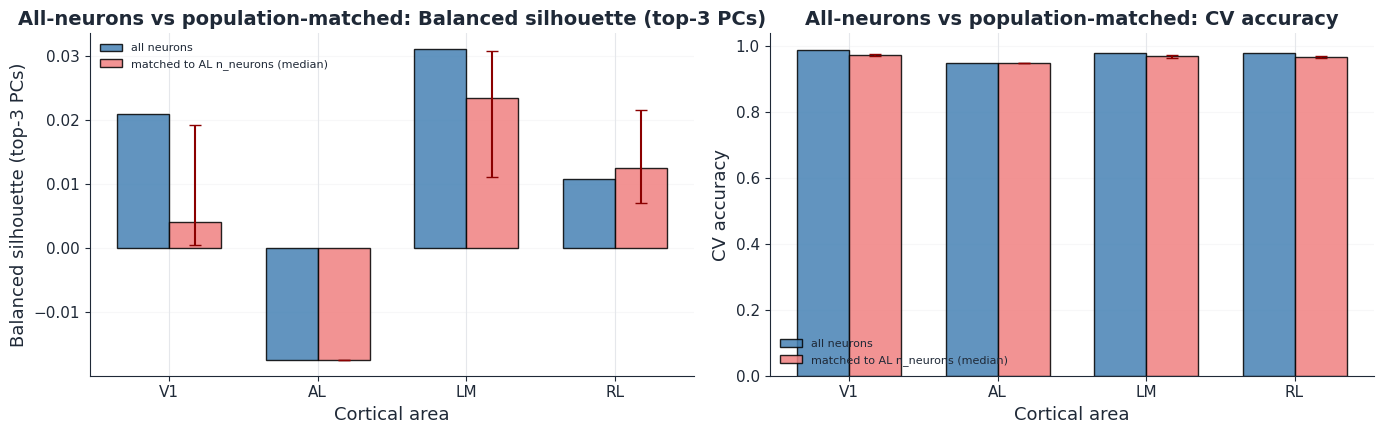

In [21]:
# Paired bar plot for each metric.
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
pca_utils.plot_population_matched_comparison(
    all_area_results, matched_results, "silhouette", ax=axes[0],
)
pca_utils.plot_population_matched_comparison(
    all_area_results, matched_results, "classifier", ax=axes[1],
)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "6_population_matched.png", dpi=150)
plt.show()

In [22]:
# Append matched-population rows to the per-session results CSV.
matched_rows = []
for area, res_list in matched_results.items():
    for metric_name in ("silhouette", "classifier"):
        observed = np.array([r[metric_name]["observed"] for r in res_list])
        per_sub_p = np.array([r[metric_name]["empirical_p"] for r in res_list])
        # Pooled per-subsample nulls: descriptive only (quantile columns).
        all_nulls = np.concatenate([r[metric_name]["null"] for r in res_list])
        # p-value: the median of the per-subsample empirical p-values. Each
        # compares one subsample's observed value with its own 100-shuffle
        # null, so its floor is 1/101 like every other p in this file.
        # (Earlier versions compared the *median* observed value against the
        # pooled 2 000 null draws; that manufactures a floor of 1/2001 for a
        # statistic whose null was never built from medians.)
        matched_rows.append({
            "area": area,
            "n_neurons": n_match,
            "metric": metric_name,
            "observed": float(np.median(observed)),
            "null_p05": float(np.quantile(all_nulls, 0.05)),
            "null_median": float(np.median(all_nulls)),
            "null_p95": float(np.quantile(all_nulls, 0.95)),
            "empirical_p_value": float(np.median(per_sub_p)),
            "n_subsamples_significant": int((per_sub_p < 0.05).sum()),
            "n_subsamples": int(len(per_sub_p)),
            "analysis": "equal_population",
        })
matched_df = pd.DataFrame(matched_rows)

# Holm-adjusted p-values, one family per metric within this analysis
# (4 areas each). Raw empirical p-values have a floor of 1/(N_SHUFFLES+1),
# so N_SHUFFLES must be large enough for alpha/m to be reachable.
df_ = matched_df
for metric_name in ("silhouette", "classifier"):
    fam = df_["metric"] == metric_name
    df_.loc[fam, "p_holm"] = pca_utils.holm_adjust(df_.loc[fam, "empirical_p_value"])
    df_.loc[fam, "n_tests"] = int(fam.sum())
matched_df = df_

# Merge into the per-session CSV (preserving all_neurons rows).
csv_path = RESULTS_DIR / "silhouette_scores.csv"
existing = pd.read_csv(csv_path) if csv_path.exists() else pd.DataFrame()
existing = existing[existing["analysis"] != "equal_population"] if len(existing) else existing
combined = pd.concat([existing, matched_df], ignore_index=True)
combined.to_csv(csv_path, index=False)
print(f"wrote {csv_path}  ({len(combined)} rows total)")
matched_df

wrote results/exp1_trial_averaged_pca/7_5/silhouette_scores.csv  (24 rows total)


,area,n_neurons,metric,observed,null_p05,null_median,null_p95,empirical_p_value,n_subsamples_significant,n_subsamples,analysis,p_holm,n_tests
0,AL,414,silhouette,-0.017560,-0.057517,-0.042278,-0.033011,0.000999,1,1,equal_population,0.003996,4.0
1,AL,414,classifier,0.947033,0.770328,0.788132,0.805788,0.000999,1,1,equal_population,0.003996,4.0
2,V1,414,silhouette,0.004056,-0.050235,-0.037430,-0.030543,0.009901,20,20,equal_population,0.029703,4.0
3,V1,414,classifier,0.973468,0.765934,0.785861,0.803639,0.009901,20,20,equal_population,0.029703,4.0
4,LM,414,silhouette,0.023403,-0.055636,-0.039831,-0.031396,0.009901,20,20,equal_population,0.029703,4.0
5,LM,414,classifier,0.969096,0.768132,0.787973,0.805739,0.009901,20,20,equal_population,0.029703,4.0
6,RL,414,silhouette,0.012521,-0.049524,-0.037438,-0.030920,0.009901,20,20,equal_population,0.029703,4.0
7,RL,414,classifier,0.965824,0.766153,0.786007,0.805763,0.009901,20,20,equal_population,0.029703,4.0


### Interpretation: equal-population control

Subsampling V1, LM, and RL down to AL's 414 neurons confirms part of what Part 5 told us, and overturns part of it.

**What it confirms.** All four areas still reliably encode the three stimulus classes. Every matched classifier stays well above chance (V1 0.973, LM 0.969, RL 0.966, AL 0.947, all p < 0.01). AL also stays at the bottom of the ranking and keeps its negative silhouette (−0.018), which is meaningful: AL is the one area we didn't subsample, so when the others get knocked down to its neuron count and it *still* lands last, that's a real coding difference. AL is genuinely the weakest area per neuron, not just because it's small. Its negative silhouette also persists under matched populations, confirming that PCA's top-3 directions in AL really don't align with the stimulus signal, that finding from Part 5 wasn't a sample-size artifact.

**What it overturns.** V1 is not actually the strongest area once we level the playing field. Its silhouette collapses from +0.021 → +0.004 (median), nearly to zero, while LM (+0.031 → +0.023) and RL (+0.011 → +0.013) barely move. The matched ranking becomes **LM > RL > V1 > AL** for silhouette, and the four areas roughly tie within ~2.7 percentage points on classifier accuracy. This rules out the "V1 dominates because of low-level feature tuning" prior we started with: per neuron, LM looks at least as informative as V1, and possibly slightly more.

**The cleanest way to think about it.** Part 5 and Part 6 are answering two different questions:

- *Total information* ("how much signal does this region as a whole carry?"): V1 wins, because it has 13× more neurons.
- *Per-neuron information* ("how informative is a typical neuron in this area?"): LM is at least as good as V1; AL is the genuine outlier on the low end.

The project's central question is **whether class structure depends on cortical area**: i.e., whether different areas organize their representations differently, not whether some areas happen to have more recorded neurons than others. Population size is an artifact of how the experiment was set up: V1 has 5,485 recorded neurons and AL has 414 because the recording window happened to cover more V1 territory, not because V1 is genuinely "13× richer" in some computational sense. Comparing all-neurons silhouettes across areas mixes two effects together: (1) how informative each area's neurons are individually (the thing we care about), and (2) how many neurons we happen to have from each area (the thing we don't).

The matched-population analysis separates these two effects by asking: "if we gave every area the same number of neurons, which one would still show the cleanest stimulus structure?" That comparison is fair, and it's the one that speaks to the underlying biology. So **the matched ranking, LM > RL > V1 > AL on silhouette, with V1/LM/RL roughly tied on classifier accuracy, is the one to cite when making claims about cortical-area differences in coding**. The all-neurons numbers are still useful as a "total information available in the recording" statement, but they shouldn't be presented as evidence that V1 is intrinsically the strongest area.

**One caveat.** V1's matched silhouette has wide subsample-to-subsample variability (individual draws ranged from −0.023 to +0.045 across the 20 replicates). This is why we run 20 subsamples and report the median with IQR error bars rather than a single draw. The width of the V1 error bar in the figure reflects this honestly.

## Part 7: log(1+x) sensitivity check

The EDA observed multiplicative noise scaling (variance ~ mean²), which is a classic sign that a `log(1+x)` variance-stabilising transform might give cleaner per-neuron statistics. We didn't make it part of the primary pipeline (it adds a step, and the simpler pipeline already delivers usable structure). But the spec calls for a **sensitivity check**: re-run the analysis with `apply_log=True` and confirm the conclusion doesn't change.

To keep this quick, we recompute **only the silhouette and classifier scalars per area** (no scatters, no scree, no equal-population control) and produce a single comparison table.

**Decision rule.** If any area moves from significant (p < 0.05) to non-significant (or vice versa), or if the cross-area ranking reorders, we report both pipelines in the writeup. If everything stays stable, we mention the robustness check in passing and stick with the primary (no-log) pipeline.

In [23]:
print("re-running preprocessing with apply_log=True...")
responses_pp_log = pca_utils.preprocess_responses(responses, apply_log=True)
per_area_log = pca_utils.build_per_area_matrices(
    responses_pp_log,
    trial_boundaries=trial_boundaries,
    clean_trial_indices=clean_trial_indices,
    brain_areas=meta["brain_areas"],
    n_frames=N_FRAMES_TRUNCATE,
)
print("  preprocessed.")

re-running preprocessing with apply_log=True...
  preprocessed.


In [24]:
log_results = {}
for area in ["V1", "AL", "LM", "RL"]:
    print(f"\n=== {area} (log pipeline) ===")
    res = pca_utils.run_area_pipeline(
        per_area_log[area], labels, area_name=area,
        n_components=N_COMPONENTS,
        n_balance_replicates=N_BALANCE_REPLICATES,
        n_shuffles=N_SHUFFLES,
        n_folds_cv=N_FOLDS_CV,
        seed=RANDOM_SEED + ord(area[0]),
    )
    log_results[area] = res
    print(f"  silhouette: obs={res['silhouette']['observed']:+.3f}  p={res['silhouette']['empirical_p']:.3f}")
    print(f"  classifier: obs={res['classifier']['observed']:.3f}  p={res['classifier']['empirical_p']:.3f}")


=== V1 (log pipeline) ===
  silhouette: obs=+0.022  p=0.001
  classifier: obs=0.989  p=0.001

=== AL (log pipeline) ===
  silhouette: obs=-0.017  p=0.001
  classifier: obs=0.960  p=0.001

=== LM (log pipeline) ===
  silhouette: obs=+0.006  p=0.001
  classifier: obs=0.987  p=0.001

=== RL (log pipeline) ===
  silhouette: obs=+0.005  p=0.001
  classifier: obs=0.982  p=0.001


In [25]:
# Side-by-side comparison table.
def _summary_row(area, res, pipeline):
    return {
        "area": area,
        "pipeline": pipeline,
        "silhouette_obs": round(res["silhouette"]["observed"], 4),
        "silhouette_p": round(res["silhouette"]["empirical_p"], 4),
        "classifier_obs": round(res["classifier"]["observed"], 4),
        "classifier_p": round(res["classifier"]["empirical_p"], 4),
    }

rows = []
for area in ["V1", "AL", "LM", "RL"]:
    rows.append(_summary_row(area, all_area_results[area], "no-log (primary)"))
    rows.append(_summary_row(area, log_results[area], "log(1+x)"))
log_compare_df = pd.DataFrame(rows)
log_compare_df

,area,pipeline,silhouette_obs,silhouette_p,classifier_obs,classifier_p
0,V1,no-log (primary),0.0210,0.001,0.9890,0.001
1,V1,log(1+x),0.0215,0.001,0.9890,0.001
2,AL,no-log (primary),-0.0176,0.001,0.9470,0.001
3,AL,log(1+x),-0.0166,0.001,0.9603,0.001
4,LM,no-log (primary),0.0312,0.001,0.9801,0.001
5,LM,log(1+x),0.0060,0.001,0.9867,0.001
6,RL,no-log (primary),0.0109,0.001,0.9779,0.001
7,RL,log(1+x),0.0047,0.001,0.9823,0.001


In [26]:
# Append log-sensitivity rows to the per-session results CSV.
log_csv_rows = []
for area, res in log_results.items():
    for metric_name in ("silhouette", "classifier"):
        m = res[metric_name]
        log_csv_rows.append({
            "area": area,
            "n_neurons": res["n_neurons"],
            "metric": metric_name,
            "observed": m["observed"],
            "null_p05": float(np.quantile(m["null"], 0.05)),
            "null_median": float(np.median(m["null"])),
            "null_p95": float(np.quantile(m["null"], 0.95)),
            "empirical_p_value": m["empirical_p"],
            "analysis": "log_sensitivity",
        })
log_df = pd.DataFrame(log_csv_rows)

# Holm-adjusted p-values, one family per metric within this analysis
# (4 areas each). Raw empirical p-values have a floor of 1/(N_SHUFFLES+1),
# so N_SHUFFLES must be large enough for alpha/m to be reachable.
df_ = log_df
for metric_name in ("silhouette", "classifier"):
    fam = df_["metric"] == metric_name
    df_.loc[fam, "p_holm"] = pca_utils.holm_adjust(df_.loc[fam, "empirical_p_value"])
    df_.loc[fam, "n_tests"] = int(fam.sum())
log_df = df_
csv_path = RESULTS_DIR / "silhouette_scores.csv"
existing = pd.read_csv(csv_path) if csv_path.exists() else pd.DataFrame()
existing = existing[existing["analysis"] != "log_sensitivity"] if len(existing) else existing
combined = pd.concat([existing, log_df], ignore_index=True)
combined.to_csv(csv_path, index=False)
print(f"wrote {csv_path}  ({len(combined)} rows total)")

wrote results/exp1_trial_averaged_pca/7_5/silhouette_scores.csv  (24 rows total)


### Interpretation: log sensitivity

**The conclusion holds: the log transform doesn't change the story, so we keep the simpler no-log pipeline as primary.**

Significance is unchanged everywhere, all eight tests (4 areas × 2 metrics) sit at p = 0.001 (p_holm = 0.004) under both pipelines. No area flips between significant and non-significant.

The classifier ranking is also stable: V1 ≈ LM > RL > AL under both pipelines, with all four areas above 96% accuracy. The numbers shift by less than 2 percentage points (e.g., AL goes 0.947 → 0.960; LM 0.980 → 0.987). This is exactly the "no qualitative change" outcome we wanted.

The silhouette numbers do shift more, LM drops from +0.031 → +0.006 and RL from +0.011 → +0.005, but neither change crosses zero or moves an area in or out of significance. The ranking does reshuffle slightly (V1 ≈ LM ≈ RL on silhouette under log, vs. LM > V1 > RL under no-log), but all three values are small and within the kind of noise we already saw across V1's 20 subsamples in Part 6 (which spanned −0.023 to +0.045).

**Bottom line.** Robustness check passes. The log(1+x) variance-stabilising transform yields the same conclusions as the simpler pipeline, so we mention this check in the writeup and stick with no-log as the primary recipe.

## Part 8: Cross-session aggregation

This cell aggregates results across any other sessions you've run this notebook on. It reads `results/exp1_trial_averaged_pca/{session}/silhouette_scores.csv` for every session present and produces a comparison plot. With one session present (the typical state during initial development on `7_5`) it produces a single-session bar plot. With ≥2 sessions, it produces a grouped bar plot showing per-area metrics across sessions.

**To replicate on another session:** change `SESSION` in the configuration block at the top, restart the kernel, and re-run the notebook. Outputs go to `figures/exp1_trial_averaged_pca/{NEW_SESSION}/` and `results/exp1_trial_averaged_pca/{NEW_SESSION}/`. This cell automatically picks them up.

In [27]:
# Aggregate across all sessions (analysis="all_neurons" by default).
results_root = RESULTS_DIR.parent
df_sil = pca_utils.aggregate_cross_session(results_root, analysis_filter="all_neurons")
df_clf = df_sil  # same DataFrame; metric column distinguishes them

n_sessions = df_sil["session"].nunique() if len(df_sil) else 0
print(f"found {n_sessions} session(s) with results: "
      f"{sorted(df_sil['session'].unique()) if n_sessions else '[]'}")

if n_sessions >= 1:
    # Write a top-level summary CSV.
    cross_csv = results_root / "cross_session_summary.csv"
    df_sil.to_csv(cross_csv, index=False)
    print(f"wrote {cross_csv}")

found 1 session(s) with results: ['7_5']
wrote results/exp1_trial_averaged_pca/cross_session_summary.csv


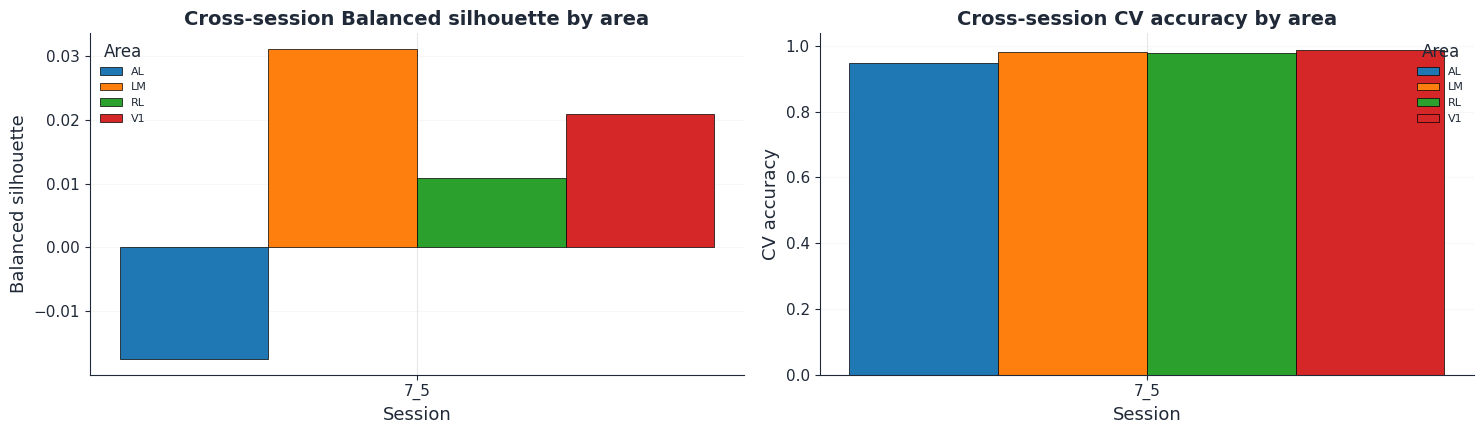

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
pca_utils.plot_cross_session_metric(df_sil, "silhouette", ax=axes[0])
pca_utils.plot_cross_session_metric(df_sil, "classifier", ax=axes[1])
fig.tight_layout()
fig.savefig(FIGURES_DIR / "8_cross_session.png", dpi=150)
plt.show()

## Part 9: Takeaways

Single summary cell capturing the headline numbers and conclusions for the writeup.

In [29]:
# Headline numbers per area (from the all-neurons analysis).
for area in ["V1", "AL", "LM", "RL"]:
    res = all_area_results[area]
    sig_sil = "✓" if res["silhouette"]["empirical_p"] < 0.05 else "✗"
    sig_clf = "✓" if res["classifier"]["empirical_p"] < 0.05 else "✗"
    print(f"{area:5s}  n={res['n_neurons']:5d}  "
          f"sil={res['silhouette']['observed']:+.3f} (p={res['silhouette']['empirical_p']:.3f}) {sig_sil}    "
          f"clf={res['classifier']['observed']:.3f} (p={res['classifier']['empirical_p']:.3f}) {sig_clf}")

# Save a plain-text headline summary for the report.
summary_path = RESULTS_DIR / "README.md"
with open(summary_path, "w") as f:
    f.write(f"# Experiment 1, session {SESSION} headline numbers\n\n")
    f.write(f"Preprocessing: detrend (per-neuron linear) -> z-score; truncate to {N_FRAMES_TRUNCATE} frames; trial-average per area.\n")
    f.write(f"Trial mask: |treadmill| > {TREADMILL_OUTLIER_THRESHOLD} dropped; n_clean = {len(clean_trial_indices)}.\n")
    f.write(f"Class composition (clean): {pd.Series(labels).value_counts().to_dict()}.\n\n")
    f.write("## Per-area headline (all-neurons analysis)\n\n")
    f.write("| Area | n_neurons | silhouette (p) | CV accuracy (p) | chance |\n")
    f.write("|---|---|---|---|---|\n")
    for area in ["V1", "AL", "LM", "RL"]:
        res = all_area_results[area]
        f.write(
            f"| {area} | {res['n_neurons']} | "
            f"{res['silhouette']['observed']:+.3f} (p={res['silhouette']['empirical_p']:.3f}) | "
            f"{res['classifier']['observed']:.3f} (p={res['classifier']['empirical_p']:.3f}) | "
            f"{res['classifier']['chance']:.3f} |\n"
        )
print(f"\nwrote {summary_path}")

V1     n= 5485  sil=+0.021 (p=0.001) ✓    clf=0.989 (p=0.001) ✓
AL     n=  414  sil=-0.018 (p=0.001) ✓    clf=0.947 (p=0.001) ✓
LM     n= 1262  sil=+0.031 (p=0.001) ✓    clf=0.980 (p=0.001) ✓
RL     n= 1033  sil=+0.011 (p=0.001) ✓    clf=0.978 (p=0.001) ✓

wrote results/exp1_trial_averaged_pca/7_5/README.md


### Headline conclusions

**All four cortical areas reliably encode the three stimulus classes.** Every per-area silhouette and classifier accuracy sits at the floor of the 1000-shuffle null (p = 0.001, Holm-adjusted p = 0.004 over the four areas). Even AL, the area with negative silhouette and the lowest accuracy, beats chance comfortably (0.947 vs. 0.832 majority baseline). So the basic claim (that V1, AL, LM, and RL all carry information distinguishing Clip from Monet2 from Trippy) is robust across areas, metrics, and the log-transform sensitivity check.

**The cross-area ranking depends on what you control for.** Using all available neurons (Part 5), V1 leads on classifier accuracy (0.989) and the four areas rank V1 > LM > RL > AL. But once we match populations to AL's 414 neurons (Part 6), V1's lead shrinks, its silhouette drops to +0.004 (median of 20 subsamples, individual draws from −0.023 to +0.045), and the matched ranking becomes **LM > RL > V1 > AL** for silhouette, with V1, LM, and RL within 0.7 percentage points on classifier accuracy (0.973 / 0.969 / 0.966; 20/20 subsamples significant per area at p_holm = 0.03). The all-neurons advantage of V1 was largely a population-size effect; per-neuron, the higher visual area LM looks at least as informative as V1, and AL is the only genuine outlier on the low end. The log(1+x) sensitivity check (Part 7) leaves significance unchanged everywhere and only nudges the numerical values, so we keep the simpler no-log pipeline as primary.

**What this says about the project's central question.** The trial-averaged population activity *does* contain stimulus-class structure in every area we measured, but two findings caution against reading "low-dimensional manifold" too literally. First, V1's overall activity geometry is genuinely high-dimensional under linear PCA, it takes 309 of 453 components to capture 95% of the variance, with no sharp elbow in the scree plot. Second, the silhouette in PC1–3 is much weaker than the full-matrix classifier accuracy in every area, and in AL the silhouette is even negative. Together these say that class identity is linearly recoverable from the population but accounts for a small share of the trial-to-trial variance, so it is not concentrated in the first principal components. PCA was not asked to separate classes, so this is not a disagreement between methods. Whether a supervised or nonlinear embedding would yield a compact class-separating representation was not tested in this repository.

**Cross-area dependence.** The structure does depend on cortical area, but not in the way the V1-strongest prior predicted. The most reliable area-level differences are: (1) AL is genuinely weaker per neuron and its discriminative directions sit furthest from PC1–3, and (2) in all four areas the Monet2 and Trippy class means sit closer to each other than to the Clip class mean in PC1–2. "Clip vs the two parametric stimuli" is a difference between stimulus sets, not evidence for a "naturalness" feature: the three classes are not controlled for low-level image statistics (luminance, contrast, motion energy), and Clip is itself a heterogeneous set of 237 movie excerpts. The fine-grained ranking among V1, LM, and RL is small and sensitive to population matching, so we treat those three as roughly comparable on this trial-averaged analysis.

**Watchouts for the time-resolved follow-up.** (No nonlinear embedding is run in this repository.) **First**, the gap between classifier accuracy (~0.99) and silhouette (~0.02) means the class signal is present in the population but occupies low-variance directions. **Second**, the high effective dimensionality (309 PCs for 95% variance) under a *linear* method doesn't rule out a low-dimensional *nonlinear* manifold; points lying on a curved sheet would force PCA to chop the geometry into many flat slices. **Third**, collapsing each trial's 75 frames into a single time-averaged vector throws away all temporal dynamics, including the stimulus-onset transient and any fast within-trial structure that might separate Monet2 from Trippy more cleanly than their averaged responses do. The fact that the two parametric stimuli look nearly identical under trial-averaging is the reason experiment 2 keeps the time axis.

## Presentation figure: V1 3-D scatter, multiple camera angles

Saves the existing `fig3d_v1` Plotly figure from the V1 3-D PCA cell to `figures/presentation/v1_3d_{angle}.svg` (+ `.png`) at each named angle. Edit `CAMERA_ANGLES` to add or replace views.

Requires `kaleido` (Plotly's static-export backend). If you get an `ImportError` or `ValueError` about kaleido, install with: `pip install -U kaleido`.

In [37]:
# Save fig3d_v1 from multiple camera angles as SVG + PNG.
# Run cell 15 (V1 3-D scatter) first so fig3d_v1 is in scope.

PRESENTATION_DIR = FIGURES_DIR / "presentation"
PRESENTATION_DIR.mkdir(parents=True, exist_ok=True)

# Edit this dict to add or replace views. `eye` is the camera position
# relative to the scene centre; bigger values = further away.
CAMERA_ANGLES = {
    "default": dict(eye=dict(x=1.5,  y=1.5,  z=1.0)),  # 3/4 view
    "front":   dict(eye=dict(x=0.0,  y=-2.0, z=0.5)),  # looking along -y
    "side":    dict(eye=dict(x=2.0,  y=0.0,  z=0.5)),  # looking along +x
    "top":     dict(eye=dict(x=0.0,  y=0.0,  z=2.2)),  # top-down
    "steep_3q":dict(eye=dict(x=1.6,  y=1.6,  z=1.6)),  # steep 3/4
}

# Output dimensions (pixels). For SVG with WebGL 3-D, this controls the
# embedded-raster resolution; for PNG, scale=2 doubles it for high-DPI slides.
WIDTH, HEIGHT = 900, 700

for name, camera in CAMERA_ANGLES.items():
    fig3d_v1.update_layout(scene_camera=camera)
    svg_path = PRESENTATION_DIR / f"v1_3d_{name}.svg"
    png_path = PRESENTATION_DIR / f"v1_3d_{name}.png"
    try:
        fig3d_v1.write_image(str(svg_path), format="svg",
                              width=WIDTH, height=HEIGHT)
        fig3d_v1.write_image(str(png_path), format="png",
                              width=WIDTH, height=HEIGHT, scale=2)
        print(f"  saved {svg_path.name}  +  {png_path.name}")
    except Exception as e:
        print(f"  FAILED {name}: {type(e).__name__}: {e}")
        print("  (if kaleido is missing: pip install -U kaleido)")
        break

Python(28893) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(28945) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


  saved v1_3d_default.svg  +  v1_3d_default.png


Python(28994) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(29021) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


  saved v1_3d_front.svg  +  v1_3d_front.png


Python(29054) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(29083) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


  saved v1_3d_side.svg  +  v1_3d_side.png


Python(29117) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(29142) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


  saved v1_3d_top.svg  +  v1_3d_top.png


Python(29180) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(29212) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


  saved v1_3d_steep_3q.svg  +  v1_3d_steep_3q.png
